In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# 將專案 root 加入 python path（讓 src/ 可以 import）
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added:", project_root)
print("✓ Imports ready")

Project root added: C:\Users\USER\Desktop\2026_japan
✓ Imports ready


In [2]:
import pandas as pd

df_pred = pd.read_parquet("../data/predictions/convlstm_df_pred.parquet")


In [3]:
import numpy as np
import pandas as pd

# df_pred 欄位: d, t, x, y, score, (count optional)
df = df_pred.copy()

# 型別保險
for c in ["d","t","x","y"]:
    df[c] = df[c].astype(int)
df["score"] = df["score"].astype(float)

# 聚合到每個格網
g = (df.groupby(["x","y"], as_index=False)
       .agg(mean_score=("score","mean"),
            max_score=("score","max"),
            std_score=("score","std"),
            n=("score","size")))

# Min-Max normalization 
mn, mx = g["mean_score"].min(), g["mean_score"].max()
eps = 1e-9
g["urban_score"] = (g["mean_score"] - mn) / (mx - mn + eps)

g.head()


,x,y,mean_score,max_score,std_score,n,urban_score
0,1,22,0.973182,1.014926,0.020987,9,0.006120
1,1,23,1.177460,2.258184,0.526102,11,0.010793
2,1,24,1.084786,2.330092,0.320807,243,0.008673
3,1,25,1.104661,2.228339,0.349343,35,0.009128
4,1,34,1.473461,2.331401,0.651960,19,0.017565


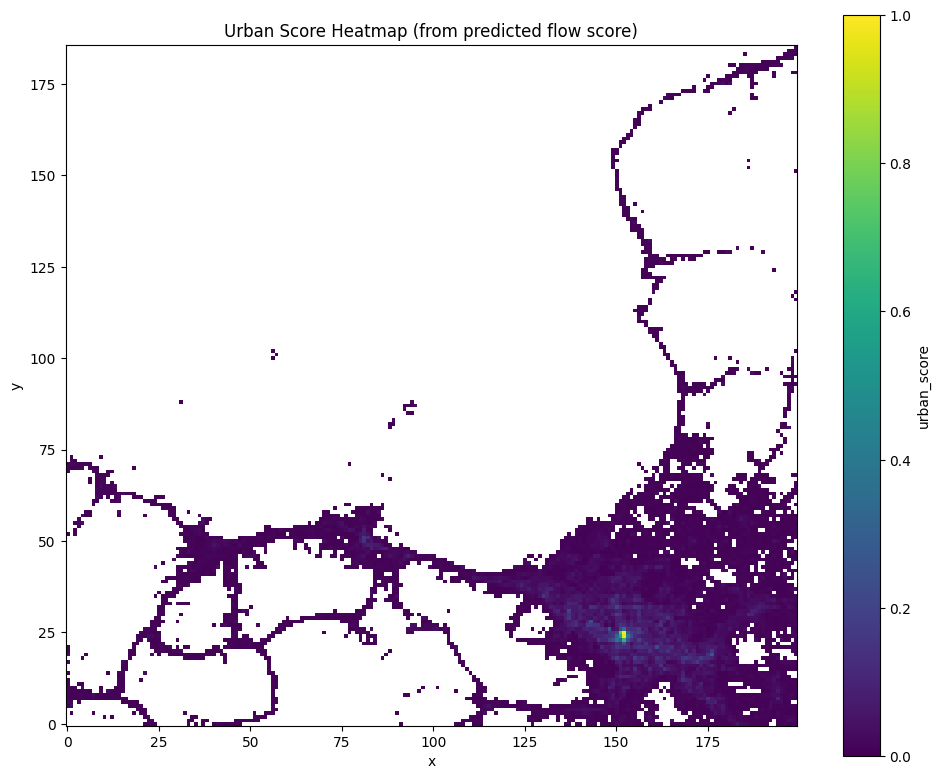

In [4]:
import matplotlib.pyplot as plt

# 轉成 2D 矩陣：row=y, col=x
mat = (g.pivot(index="y", columns="x", values="urban_score")
         .sort_index(axis=0)   # y 排序
         .sort_index(axis=1))  # x 排序
A = mat.values
A_90 = np.rot90(A, 3)
A_lr = np.fliplr(A_90)
plt.figure(figsize=(10, 8))
im = plt.imshow(A_lr, origin="lower", aspect="equal")
plt.colorbar(im, label="urban_score")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Urban Score Heatmap (from predicted flow score)")
plt.tight_layout()
plt.show()


In [5]:
import numpy as np
import pandas as pd

def synthesize_parking_lots(
    g, 
    seed=42,
    lambda_min=0.02,   # 郊區每格網平均 0.02 個（約 50 格出 1 個）
    lambda_max=0.35,   # 市區每格網平均 0.35 個（約 3 格出 1 個）
    gamma=1.8,         # >1 讓市區更集中
    city_cap_range=(15, 30), # 市區格數範圍
    suburb_cap_range=(60, 120), # 郊區格數範圍
    city_threshold=0.3,  # 超過當市區
    jitter=True
):
    rng = np.random.default_rng(seed) #可重現停車場資料

    grid = g[["x","y","urban_score"]].copy()
    u = grid["urban_score"].to_numpy()

    # 每格網的期望停車場數 
    lam = lambda_min + (lambda_max - lambda_min) * np.power(u, gamma)

    # 每格網用 Poisson 分布隨機產生要生成幾個停車場
    k = rng.poisson(lam)

    rows = []
    park_id = 0

    for (x, y, us, kk) in zip(grid["x"].to_numpy(), grid["y"].to_numpy(), u, k):
        if kk <= 0:
            continue

        is_city = (us >= city_threshold)

        # 容量範圍（市區/郊區）
        cap_lo, cap_hi = city_cap_range if is_city else suburb_cap_range

        for _ in range(kk):
            park_id += 1

            # 停車場座標：先用格網座標；可加 jitter 讓多個停車場在格網內隨機偏移而不重疊
            if jitter:
                px = x + rng.uniform(-0.35, 0.35)
                py = y + rng.uniform(-0.35, 0.35)
            else:
                px, py = float(x), float(y)

            capacity = int(rng.integers(cap_lo, cap_hi + 1))
 
            rows.append({
                "park_id": park_id,
                "grid_x": int(x),
                "grid_y": int(y),
                "park_x": float(px),
                "park_y": float(py),
                "urban_score": float(us),
                "is_city": int(is_city),
                "capacity": capacity
            })

    df_parks = pd.DataFrame(rows)
    return df_parks

city_q = 0.7
city_threshold = g["urban_score"].quantile(city_q)

df_parks = synthesize_parking_lots(g, seed=2026, city_threshold=city_threshold)
df_parks.head(), len(df_parks)
#df_parks.to_csv("sapporo_synthetic_parking_lots.csv", index=False)

(   park_id  grid_x  grid_y    park_x      park_y  urban_score  is_city  \
 0        1       1     185  0.933908  185.030703     0.026051        1   
 1        2       4     130  3.920186  129.930470     0.014798        0   
 2        3       4     137  4.005032  137.319110     0.012113        0   
 3        4       4     146  3.922324  146.111331     0.009512        0   
 4        5       4     159  4.228922  158.698902     0.005935        0   
 
    capacity  
 0        26  
 1        90  
 2        91  
 3       120  
 4        70  ,
 144)

In [6]:
# 市區/郊區數量對比
summary = (df_parks.groupby("is_city")
           .agg(n_parks=("park_id","count"),
                mean_cap=("capacity","mean"),
                med_cap=("capacity","median"),
                capacity=("capacity","sum"))
          )
summary['avg_cap'] = summary['capacity'] / summary['n_parks']
summary



,n_parks,mean_cap,med_cap,capacity,avg_cap
is_city,,,,,
0,98,90.357143,91.0,8855,90.357143
1,46,22.543478,22.0,1037,22.543478


In [21]:
import numpy as np
import pandas as pd
''' 
    baseline f(x) =>
        a_city : 市區人流與車轉換率 , a_suburb : 郊區人流與車轉換率

    time factor f(x) =>
        A_m : 早上通勤尖峰加成 , A_e : 傍晚通勤尖峰加成 , A_w : 周末通勤尖峰加成
        sig_m : 早上通勤尖峰長度 , sig_e : 包晚通勤尖峰長度 , sig_w : 周末通勤尖峰長度

    event boost f(x) =>
        z : 網格人流當下的 Z-Score , beta : 事件加成倍率
'''
def build_a(df_pred, g, step_minutes=30,
            a_city=0.10, a_suburb=0.35, gamma=2.0,
            A_m=0.15, A_e=0.15, A_w=0.10,
            sig_m=1.0, sig_e=1.75, sig_w=4.0,
            beta=0.08, a_min=0.02, a_max=0.70):
    df = df_pred.copy()
    df["score"] = df["score"].astype(float)

    # merge urban_score
    df = df.merge(g[["x","y","urban_score"]], on=["x","y"], how="left")
    df["urban_score"] = df["urban_score"].fillna(df["urban_score"].median())

    # ===== (A) a_base from urban_score =====
    sub = 1.0 - df["urban_score"].to_numpy() # sub 越接近 1 越像郊區
    a_base = a_city + (a_suburb - a_city) * np.power(sub, gamma)

    # ===== (B) time factor =====
    hour = df["t"].to_numpy() * (step_minutes / 60.0)

    # 週末判斷
    df["date"] = pd.to_datetime("2019-09-15") + pd.to_timedelta(df["d"], unit="D")
    df["weekday"] = df["date"].dt.weekday
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)
    is_weekend = df["is_weekend"].to_numpy(dtype=float)

    # 高斯常態分佈(mu : 最高峰的時間)
    def gauss(h, mu, sig):
        return np.exp(-0.5 * ((h - mu) / sig) ** 2)

    # 1 是基底之倍率
    f_time = (
        1.0
        + A_m * gauss(hour, 8.0,  sig_m)
        + A_e * gauss(hour, 17.0, sig_e)
        + is_weekend * A_w * gauss(hour, 13.0, sig_w)
    )

    # ===== (C) event boost from z-score per grid =====
    grid_stats = (df.groupby(["x","y"])["score"]
                    .agg(["mean","std"])
                    .rename(columns={"mean":"mu","std":"sd"})
                    .reset_index())
    df = df.merge(grid_stats, on=["x","y"], how="left")
    z = (df["score"].to_numpy() - df["mu"].to_numpy()) / (df["sd"].to_numpy() + 1e-9) # z=0:平均值,z=1:比平常高一個std,z<0:比平常低不須加成 
    df['z'] = z    
    f_event = 1.0 + beta * np.maximum(0.0, z)

    # ===== final a =====
    # a_base : 區域特性 , f_time : 2; 當天內時段加成 , f_event : 局部事件加成
    a = a_base * f_time * f_event
    a = np.clip(a, a_min, a_max)

    df["a"] = a
    return df.drop(columns=["mu","sd"])

df_with_a = build_a(df_pred, g)

In [26]:
df_with_a.head()

,d,t,x,y,score,count,urban_score,date,weekday,is_weekend,z,a
0,32,18,1,22,0.941464,1,0.00612,2019-10-17,3,0,-1.511268,0.378516
1,26,20,1,22,0.969777,1,0.00612,2019-10-11,4,0,-0.162259,0.354010
2,31,20,1,22,0.982814,1,0.00612,2019-10-16,2,0,0.458969,0.367008
3,43,21,1,22,0.984589,1,0.00612,2019-10-28,0,0,0.543536,0.364477
4,52,21,1,22,0.976331,1,0.00612,2019-11-06,2,0,0.150044,0.353481


            mean    median       std    count
zone                                         
city    0.352308  0.346637  0.039922  4340479
suburb  0.379174  0.376096  0.031997  1468058


C:\Users\USER\AppData\Local\Temp\ipykernel_17488\1964054801.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=zones, patch_artist=True,showfliers=False,


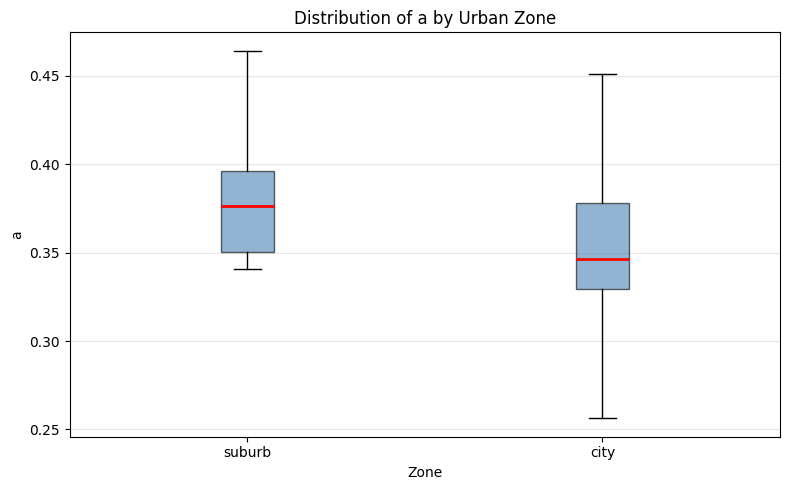

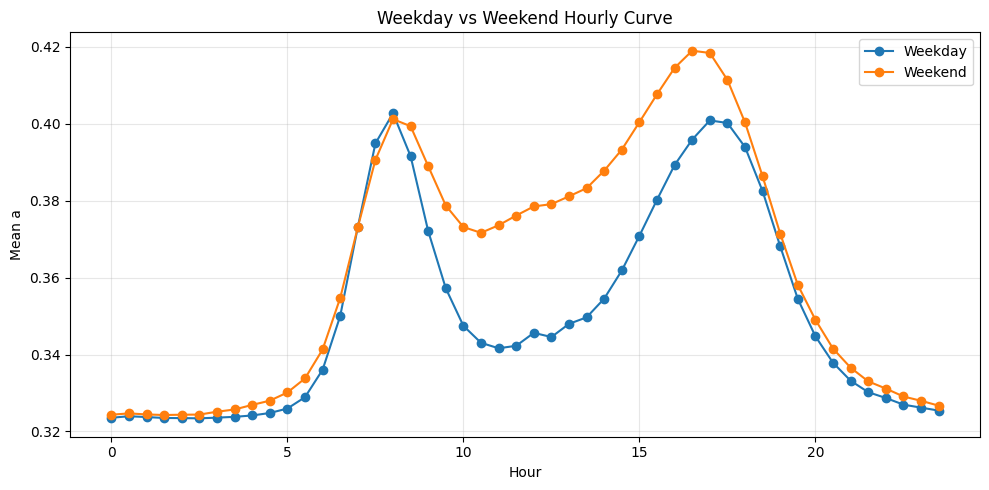

    z_bin    mean_a  median_a        n
0    z<=0  0.343317  0.341487  3117264
1  0<z<=1  0.364167  0.364209  1752122
2  1<z<=2  0.392516  0.395138   754962
3     z>2  0.440991  0.441079   184189
           score         a      cars
zone                                
city    3.401937  0.352308  1.163947
suburb  1.260544  0.379174  0.485309


In [25]:
import numpy as np
import pandas as pd

df = df_with_a.copy()
df["hour"] = df["t"] * 0.5

# merge urban_score（若 df 已有可略）
if "urban_score" not in df.columns:
    df = df.merge(g[["x","y","urban_score"]], on=["x","y"], how="left")


# B1) 市區 vs 郊區
df["zone"] = np.where(df["urban_score"] >= city_threshold, "city", "suburb")
print(df.groupby("zone")["a"].agg(["mean","median","std","count"]))

# 畫箱型圖
zones = ["suburb", "city"]
data  = [df[df["zone"] == z]["a"].dropna().values for z in zones]
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(data, labels=zones, patch_artist=True,showfliers=False,
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           medianprops=dict(color="red", linewidth=2))

ax.set_xlabel("Zone")
ax.set_ylabel("a")
ax.set_title("Distribution of a by Urban Zone")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# B2) 時段曲線
curve = (df.groupby(["is_weekend","hour"])["a"].mean()
           .reset_index()
           .sort_values(["is_weekend","hour"]))
fig, ax = plt.subplots(figsize=(10, 5))

for is_weekend, group in curve.groupby("is_weekend"):
    label = "Weekend" if is_weekend else "Weekday"
    ax.plot(group["hour"], group["a"], marker="o", label=label)

ax.set_xlabel("Hour")
ax.set_ylabel("Mean a")
ax.set_title("Weekday vs Weekend Hourly Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# B3) Z分桶
# 分桶
bins   = [-np.inf, 0, 1, 2, np.inf]
labels = ["z<=0", "0<z<=1", "1<z<=2", "z>2"]
df["z_bin"] = pd.cut(df["z"], bins=bins, labels=labels, right=True)

# 每桶 mean(a)
res = (df.groupby("z_bin", observed=True)
         .agg(mean_a=("a","mean"),
              median_a=("a","median"),
              n=("a","size"))
         .reset_index())

print(res)

# C) cars 檢查
df["cars"] = df["a"] * df["score"]
print(df.groupby("zone")[["score","a","cars"]].mean())

In [46]:
import numpy as np
import pandas as pd

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def build_parking_prob_baseline(
    df_with_a: pd.DataFrame,     # d,t,x,y,score,a
    df_parks: pd.DataFrame,      # park_id, park_x, park_y, capacity
    *,
    kappa: float = 1.0,          # car_demand = kappa * a * score
    R: float = 3.0,              # 看半徑 R 內的格網
    R_choice: float = 3.0,         # R_choice內的停車場人流會較偏好去停 
    sigma: float = 1.5,          # 控制距離衰減速度
    sigma_choice: float = 1.5,   # 控制距離偏好衰減（越小越只選近的）
    theta0: float = 2.0,         # sigmoid 截距(控制整體偏高/偏低，越大sigmoid越接近1，越容易有位)
    theta1: float = 6.0,         # sigmoid 斜率(控制停車需求對滿位的敏感程度)
    cap_beta: float = 0.3,       # 容量加成（大停車場更容易被選，0=不考慮）
) -> pd.DataFrame:

    df = df_with_a.copy()
    parks = df_parks.copy()

    # grid-level car demand
    df["car_demand"] = kappa * df["a"].astype(float) * df["score"].astype(float)

    # 建立格網索引，把每個(x,y)映射成整數索引
    grid_xy = df[["x","y"]].drop_duplicates().copy()
    grid_xy["grid_idx"] = np.arange(len(grid_xy), dtype=int)

    # 把 grid_idx merge 回 df
    df = df.merge(grid_xy, on=["x","y"], how="left")

    # park_id -> 連續索引 park_pos（方便用 numpy 陣列累加）
    park_ids = parks["park_id"].to_numpy(dtype=int)

    px_all = parks["park_x"].to_numpy(dtype=float)
    py_all = parks["park_y"].to_numpy(dtype=float)
    cap_all = parks["capacity"].to_numpy(dtype=float)
    n_parks = len(parks)

    # 對每一個格網先找出它附近會被考慮的停車場候選集合，然後用距離(+容量)算出這個格網的車流會選哪個停車場的機率分布 
    grid_records = [(np.array([], dtype=int), np.array([], dtype=float)) for _ in range(len(grid_xy))]
    for row in grid_xy.itertuples(index=False):
        gx0, gy0, gidx = float(row.x), float(row.y), int(row.grid_idx)

        dx = px_all - gx0
        dy = py_all - gy0
        dist2 = dx*dx + dy*dy
        mask = dist2 <= R_choice*R_choice

        park_poss = np.where(mask)[0]
        if len(park_poss) == 0:
            # 若R_choice內都沒停車場則取最近 K 個停車場當候選
            K = 5
            cand_poss = np.argsort(dist2)[:K].astype(int)
        else:
            cand_poss = park_poss.astype(int)

        dist2_select = dist2[cand_poss]

        # 用高斯衰減計算吸引力權重，越近越容易被想到
        w_choice = np.exp(-dist2_select / (2.0 * sigma_choice * sigma_choice))

        # 用高斯衰減計算競爭權重，越大代表那個格網的車流需求，對該停車場的影響越高。可理解為競爭強度
        w_comp = np.exp(-dist2_select / (2.0 * sigma * sigma))

        # w_choice * w_comp * capacity加成
        attr = w_choice * w_comp * np.power(cap_all[cand_poss], cap_beta)

        # 正規化成機率 P(p|g)
        probs = attr / (attr.sum() + 1e-12)
        grid_records[gidx] = (cand_poss, probs.astype(float))

    # 逐時間片(d,t)聚合 demand(每一個時間(d,t)下，計算每一個停車場周邊所有格網的車流需求加總(含距離權重)，得到該停車場的demand(park,d,t))
    out_rows = []
    # 用 groupby (d,t) 取出該時間所有 grid 的 car_demand 向量
    for (d, t), sub in df.groupby(["d","t"], sort=False):
        # 存每個停車場的 demand（用 park_pos 當索引）
        demand_vec = np.zeros(n_parks, dtype=float)

        tmp = sub.groupby("grid_idx", as_index=False)["car_demand"].sum() # 聚合避免重複計算
        gidxs = tmp["grid_idx"].to_numpy(dtype=int)
        flows = tmp["car_demand"].to_numpy(dtype=float)

        # 將每個格網的車流依機率 P(park|grid) 分配到候選停車場，且機率總合為1，每個格網的車流需求會被完整分配出去
        for gidx, flow in zip(gidxs, flows):
            park_poss, probs = grid_records[gidx]   # grid_records 的順序就是 grid_idx
            if len(park_poss) == 0:
                continue
            demand_vec[park_poss] += flow * probs

        # 由 demand 算 p_avail
        for pos, pid in enumerate(park_ids):
            cap = cap_all[pos]
            demand = float(demand_vec[pos])
            pressure = demand / (cap + 1e-9)
            p_avail = float(sigmoid(theta0 - theta1 * pressure)) # 可停車機率

            out_rows.append({
                "d": int(d),
                "t": int(t),
                "park_id": int(pid),
                "demand": demand,
                "pressure": pressure,
                "p_avail": p_avail,
            })

    return pd.DataFrame(out_rows)

In [47]:
df_prob = build_parking_prob_baseline(df_with_a, df_parks)

# 把停車場位置/容量/市區標籤合併回來
df_prob = df_prob.merge(
    df_parks[["park_id", "park_x", "park_y", "capacity"] + 
             [c for c in ["is_city", "urban_score"] if c in df_parks.columns]],
    on="park_id",
    how="left"
)
df_prob.head()

,d,t,park_id,demand,pressure,p_avail,park_x,park_y,capacity,is_city,urban_score
0,32,18,1,9.837369,0.378360,0.432867,0.933908,185.030703,26,1,0.026051
1,32,18,2,1.673255,0.018592,0.868579,3.920186,129.930470,90,0,0.014798
2,32,18,3,9.007749,0.098986,0.803147,4.005032,137.319110,91,0,0.012113
3,32,18,4,18.832252,0.156935,0.742382,3.922324,146.111331,120,0,0.009512
4,32,18,5,1.087445,0.015535,0.870658,4.228922,158.698902,70,0,0.005935


In [48]:
# 每個時間片的總 car_demand
df_tmp = df_with_a.copy()
df_tmp["car_demand"] = 1.0 * df_tmp["a"].astype(float) * df_tmp["score"].astype(float)  # kappa=1.0時
total_flow = df_tmp.groupby(["d","t"])["car_demand"].sum().reset_index(name="total_car_demand")

# 每個時間片分配到停車場的總 demand
total_assigned = df_prob.groupby(["d","t"])["demand"].sum().reset_index(name="total_assigned_demand")

chk = total_flow.merge(total_assigned, on=["d","t"], how="left")
chk["assign_ratio"] = chk["total_assigned_demand"] / (chk["total_car_demand"] + 1e-12)

chk.head()

,d,t,total_car_demand,total_assigned_demand,assign_ratio
0,1,0,396.712468,393.124190,0.990955
1,1,1,395.392957,391.099337,0.989141
2,1,2,373.282110,368.794930,0.987979
3,1,3,347.164723,342.668526,0.987049
4,1,4,321.798609,316.318161,0.982969


511488


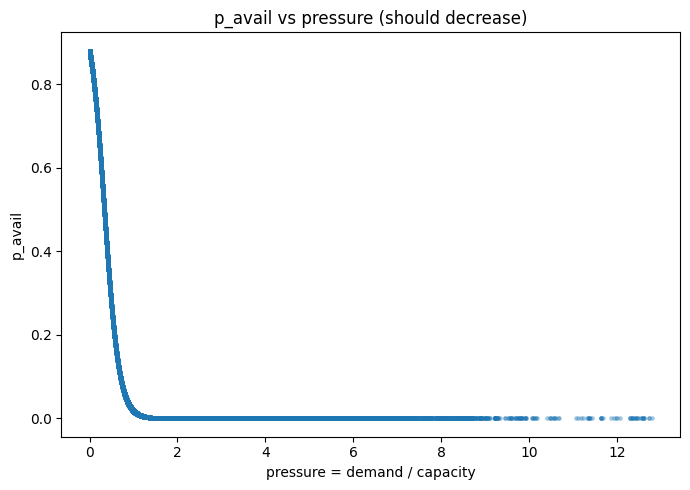

In [49]:
import matplotlib.pyplot as plt

print(len(df_prob))
sample = df_prob.sample(min(200000, len(df_prob)), random_state=0)

plt.figure(figsize=(7,5))
plt.scatter(sample["pressure"], sample["p_avail"], s=6, alpha=0.3)
plt.xlabel("pressure = demand / capacity")
plt.ylabel("p_avail")
plt.title("p_avail vs pressure (should decrease)")
plt.tight_layout()
plt.show()

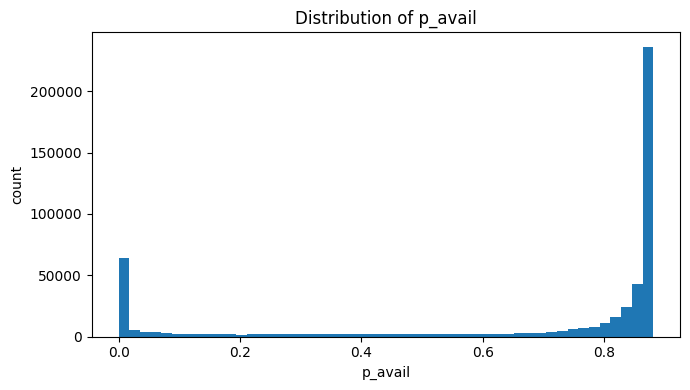

In [50]:
plt.figure(figsize=(7,4))
plt.hist(df_prob["p_avail"].to_numpy(), bins=50)
plt.xlabel("p_avail")
plt.ylabel("count")
plt.title("Distribution of p_avail")
plt.tight_layout()
plt.show()

mean p_avail by is_city:
 is_city
0    0.834360
1    0.298024
Name: p_avail, dtype: float64


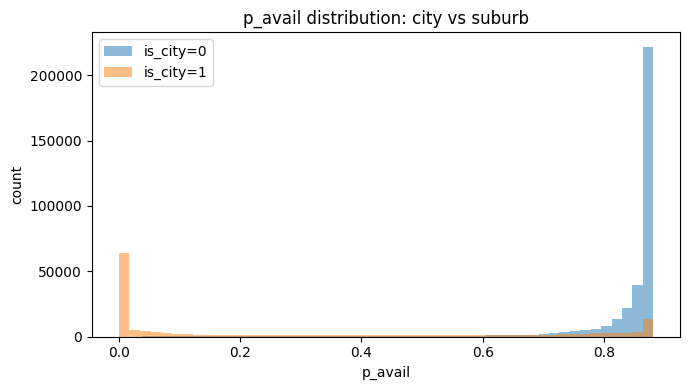

In [51]:
if "is_city" in df_prob.columns:
    g = df_prob.groupby("is_city")["p_avail"].mean()
    print("mean p_avail by is_city:\n", g)

    plt.figure(figsize=(7,4))
    for flag, sub in df_prob.groupby("is_city"):
        plt.hist(sub["p_avail"].to_numpy(), bins=50, alpha=0.5, label=f"is_city={flag}")
    plt.xlabel("p_avail")
    plt.ylabel("count")
    plt.title("p_avail distribution: city vs suburb")
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_17488\1775571324.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
C:\Users\USER\AppData\Local\Temp\ipykernel_17488\1775571324.py:14: UserWarning: Glyph 37066 (\N{CJK UNIFIED IDEOGRAPH-90CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17488\1775571324.py:14: UserWarning: Glyph 21312 (\N{CJK UNIFIED IDEOGRAPH-5340}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_17488\1775571324.py:14: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\Desktop\2026_japan\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37066 (\N{CJK UNIFIED IDEOGRAPH-90CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

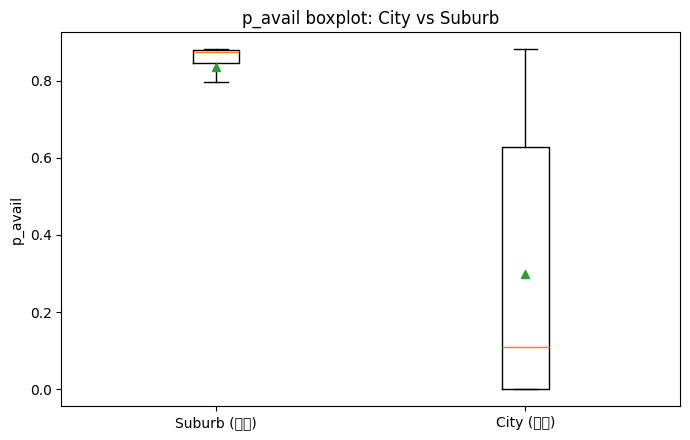

Suburb: {'n': 348096, 'mean': 0.8343597765204162, 'median': 0.8731688742835938, 'q1': 0.8466405857009028, 'q3': 0.8802050131959875}
City  : {'n': 163392, 'mean': 0.2980235623803971, 'median': 0.11003218166137974, 'q1': 0.000998775549655544, 'q3': 0.6268295219891568}


In [56]:
# 準備兩組資料
suburb = df_prob.loc[df_prob["is_city"] == 0, "p_avail"].dropna().to_numpy()
city   = df_prob.loc[df_prob["is_city"] == 1, "p_avail"].dropna().to_numpy()

plt.figure(figsize=(7, 4.5))
plt.boxplot(
    [suburb, city],
    labels=["Suburb (郊區)", "City (市區)"],
    showmeans=True,
    showfliers=False
)
plt.ylabel("p_avail")
plt.title("p_avail boxplot: City vs Suburb")
plt.tight_layout()
plt.show()

# （可選）印出摘要數字，方便你報告引用
def summary(arr):
    return {
        "n": len(arr),
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "q1": float(np.quantile(arr, 0.25)),
        "q3": float(np.quantile(arr, 0.75)),
    }

print("Suburb:", summary(suburb))
print("City  :", summary(city))

day 1 off-peak t= 6 peak t= 35


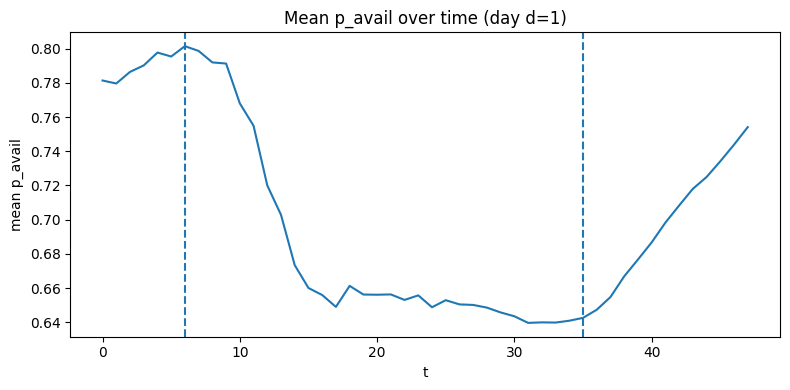

In [52]:
flow_by_t = (df_tmp.groupby(["d","t"])["car_demand"].sum().reset_index())
# 先挑某一天 d0（你也可以改成迴圈跑全部天）
d0 = int(flow_by_t["d"].min())
tmpd = flow_by_t[flow_by_t["d"] == d0].sort_values("car_demand")
t_off = int(tmpd.iloc[0]["t"])
t_peak = int(tmpd.iloc[-1]["t"])
print("day", d0, "off-peak t=", t_off, "peak t=", t_peak)

# 畫該天每個時間片的平均 p_avail
mean_p = (df_prob[df_prob["d"]==d0].groupby("t")["p_avail"].mean().reset_index())

plt.figure(figsize=(8,4))
plt.plot(mean_p["t"], mean_p["p_avail"])
plt.axvline(t_off, linestyle="--")
plt.axvline(t_peak, linestyle="--")
plt.xlabel("t")
plt.ylabel("mean p_avail")
plt.title(f"Mean p_avail over time (day d={d0})")
plt.tight_layout()
plt.show()

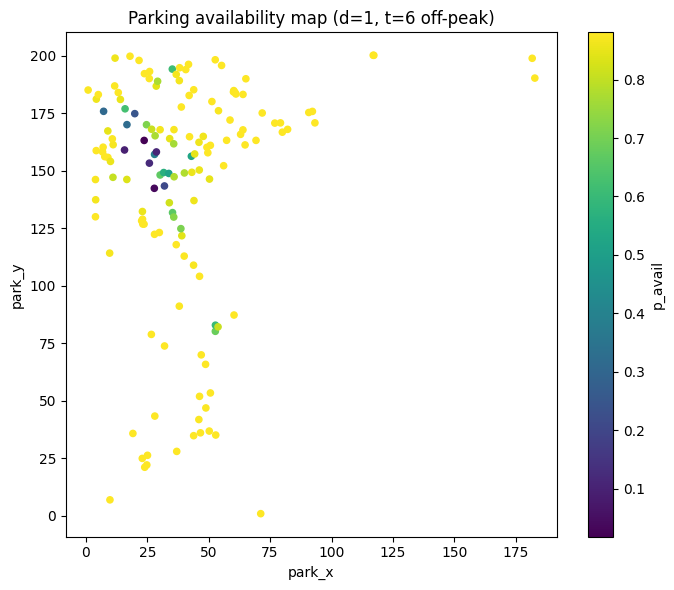

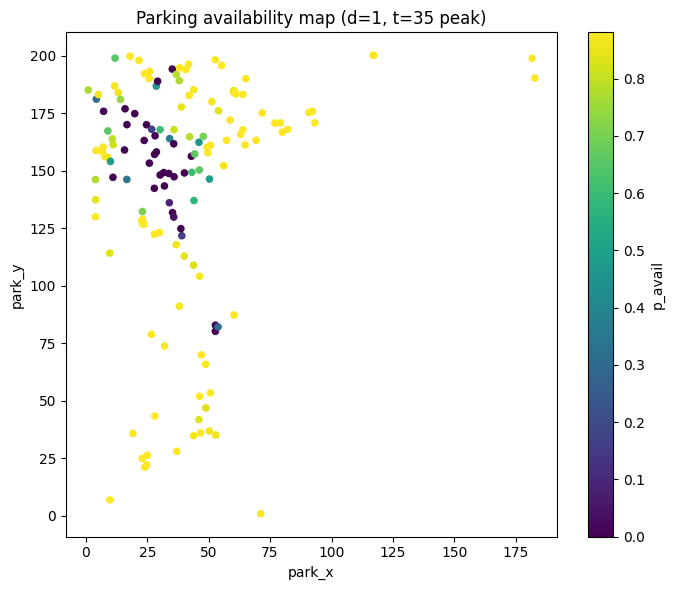

In [53]:
def plot_parks_map(df_prob, d, t, title):
    sub = df_prob[(df_prob["d"]==d) & (df_prob["t"]==t)].copy()
    plt.figure(figsize=(7,6))
    sc = plt.scatter(sub["park_x"], sub["park_y"], c=sub["p_avail"], s=20)
    plt.colorbar(sc, label="p_avail")
    plt.xlabel("park_x")
    plt.ylabel("park_y")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_parks_map(df_prob, d0, t_off,  f"Parking availability map (d={d0}, t={t_off} off-peak)")
plot_parks_map(df_prob, d0, t_peak, f"Parking availability map (d={d0}, t={t_peak} peak)")